In [ ]:
import subprocess, sys
def pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)
pip("datasets>=2.19", "datasketch", "tiktoken", "pandas", "matplotlib", "tqdm")

import re, math, random, collections
from urllib.parse import urlparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset

random.seed(0); np.random.seed(0)
pd.set_option("display.max_colwidth", 90)

In [ ]:
N_DOCS = 3000
print(f"Streaming {N_DOCS} docs from FineWeb sample-10BT ...")

stream = load_dataset(
    "HuggingFaceFW/fineweb",
    name="sample-10BT",
    split="train",
    streaming=True,
)

docs = []
for i, doc in enumerate(tqdm(stream, total=N_DOCS)):
    docs.append(doc)
    if i + 1 >= N_DOCS:
        break

df = pd.DataFrame(docs)
print("\nColumns:", list(df.columns))
print(df[["url", "language", "language_score", "token_count"]].head(5))

ex = docs[0]
print("\n--- Example record (fields) ---")
for k, v in ex.items():
    preview = (v[:120] + "…") if isinstance(v, str) and len(v) > 120 else v
    print(f"{k:>16}: {preview}")

In [ ]:
WORD = re.compile(r"\b\w+\b")

def gopher_quality(text):
    words = WORD.findall(text)
    n = len(words)
    if n < 50 or n > 100_000:
        return False, "word_count_out_of_range"
    mean_len = sum(len(w) for w in words) / n
    if mean_len < 3 or mean_len > 10:
        return False, "bad_mean_word_length"
    if (text.count("#") + text.count("...")) / n > 0.1:
        return False, "too_many_symbols"
    lines = text.split("\n")
    if lines and sum(l.lstrip().startswith(("•", "-", "*")) for l in lines) / len(lines) > 0.9:
        return False, "mostly_bullets"
    stops = {"the", "be", "to", "of", "and", "that", "have", "with"}
    if len(stops & {w.lower() for w in words}) < 2:
        return False, "too_few_stopwords"
    return True, "ok"

def c4_quality(text):
    lines = [l for l in text.split("\n") if l.strip()]
    if not lines:
        return False, "empty"
    low = text.lower()
    for bad in ("lorem ipsum", "javascript is disabled"):
        if bad in low:
            return False, f"boilerplate:{bad}"
    if text.count("{") > 0 and text.count("{") / max(len(lines), 1) > 0.5:
        return False, "too_many_braces"
    return True, "ok"

def fineweb_custom(text):
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    if not lines:
        return False, "empty"
    dup_frac = 1 - len(set(lines)) / len(lines)
    if dup_frac > 0.3:
        return False, "duplicated_lines"
    short_frac = sum(len(l) < 30 for l in lines) / len(lines)
    if short_frac > 0.67 and len(lines) > 5:
        return False, "list_like"
    return True, "ok"

results = []
for d in docs:
    t = d["text"]
    g_ok, g_r = gopher_quality(t)
    c_ok, c_r = c4_quality(t)
    f_ok, f_r = fineweb_custom(t)
    reason = "kept" if (g_ok and c_ok and f_ok) else (g_r if not g_ok else c_r if not c_ok else f_r)
    results.append(reason)

filter_summary = pd.Series(results).value_counts()
print("\n--- Quality-filter outcomes on already-clean FineWeb data ---")
print("(Most pass: FineWeb is pre-filtered. Rejections show what the rules catch.)")
print(filter_summary)

In [ ]:
from datasketch import MinHash, MinHashLSH

def shingles(text, k=5):
    toks = WORD.findall(text.lower())
    return {" ".join(toks[i:i+k]) for i in range(max(len(toks) - k + 1, 1))}

NUM_PERM = 128
THRESHOLD = 0.7
lsh = MinHashLSH(threshold=THRESHOLD, num_perm=NUM_PERM)
minhashes = {}

for idx, d in enumerate(tqdm(docs, desc="MinHashing")):
    m = MinHash(num_perm=NUM_PERM)
    for s in shingles(d["text"]):
        m.update(s.encode("utf8"))
    minhashes[idx] = m
    lsh.insert(str(idx), m)

dup_pairs = set()
for idx, m in minhashes.items():
    for cand in lsh.query(m):
        c = int(cand)
        if c != idx:
            dup_pairs.add(tuple(sorted((idx, c))))

print(f"\nFound {len(dup_pairs)} near-duplicate pairs (Jaccard ≥ {THRESHOLD}).")
if dup_pairs:
    a, b = next(iter(dup_pairs))
    j = minhashes[a].jaccard(minhashes[b])
    print(f"Example pair (estimated Jaccard ≈ {j:.2f}):")
    print("  DOC A:", docs[a]["text"][:160].replace("\n", " "), "…")
    print("  DOC B:", docs[b]["text"][:160].replace("\n", " "), "…")
else:
    print("No near-dupes in this slice — expected, since FineWeb is dedup'd per crawl.")

In [ ]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

check = docs[:200]
recomputed = [len(enc.encode(d["text"])) for d in tqdm(check, desc="Tokenizing")]
stored = [d["token_count"] for d in check]
diffs = np.array(recomputed) - np.array(stored)
print(f"\n--- Verifying token_count field (gpt2) on 200 docs ---")
print(f"Mean abs diff vs stored token_count: {np.abs(diffs).mean():.2f} tokens")
print(f"Exact matches: {(diffs == 0).mean()*100:.0f}%   (small drift = tokenizer version)")

df["chars_per_token"] = df["text"].str.len() / df["token_count"].clip(lower=1)
print(f"Avg characters per token: {df['chars_per_token'].mean():.2f}")

Streaming 3000 docs from FineWeb sample-10BT ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/44.3k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/27468 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


Columns: ['text', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'token_count']
                                                                                         url  \
0                                http://daytimeroyaltyonline.com/single/?p=8906650&t=8780053   
1  http://endogenousretrovirus.blogspot.com/2007/11/if-you-have-set-yourself-on-fire-do-n...   
2                                                             http://news.cancerconnect.com/   
3      http://sharingsolution.com/2009/05/23/free-the-cans-working-together-to-reduce-waste/   
4         http://supermarketnews.com/food-safety/more-suppliers-sought-rapid-recall-exchange   

  language  language_score  token_count  
0       en        0.823210          142  
1       en        0.973771          703  
2       en        0.872709          576  
3       en        0.932360          575  
4       en        0.955206          708  

--- Example record (fields) ---
            text: |Viewing Singl

MinHashing:   0%|          | 0/3000 [00:00<?, ?it/s]


Found 0 near-duplicate pairs (Jaccard ≥ 0.7).
No near-dupes in this slice — expected, since FineWeb is dedup'd per crawl.


Tokenizing:   0%|          | 0/200 [00:00<?, ?it/s]


--- Verifying token_count field (gpt2) on 200 docs ---
Mean abs diff vs stored token_count: 0.29 tokens
Exact matches: 94%   (small drift = tokenizer version)
Avg characters per token: 4.39

--- Top 15 domains in sample ---
domain
bloomberg.com                  5
bleacherreport.com             4
theguardian.com                4
cnet.com                       4
rutlandherald.com              4
djournal.com                   3
heraldnet.com                  3
businessinsider.com            3
sciencedaily.com               3
basspro.com                    3
nj.com                         3
tvtechnology.com               3
csmonitor.com                  3
articles.chicagotribune.com    3
eetimes.com                    3
Name: count, dtype: int64


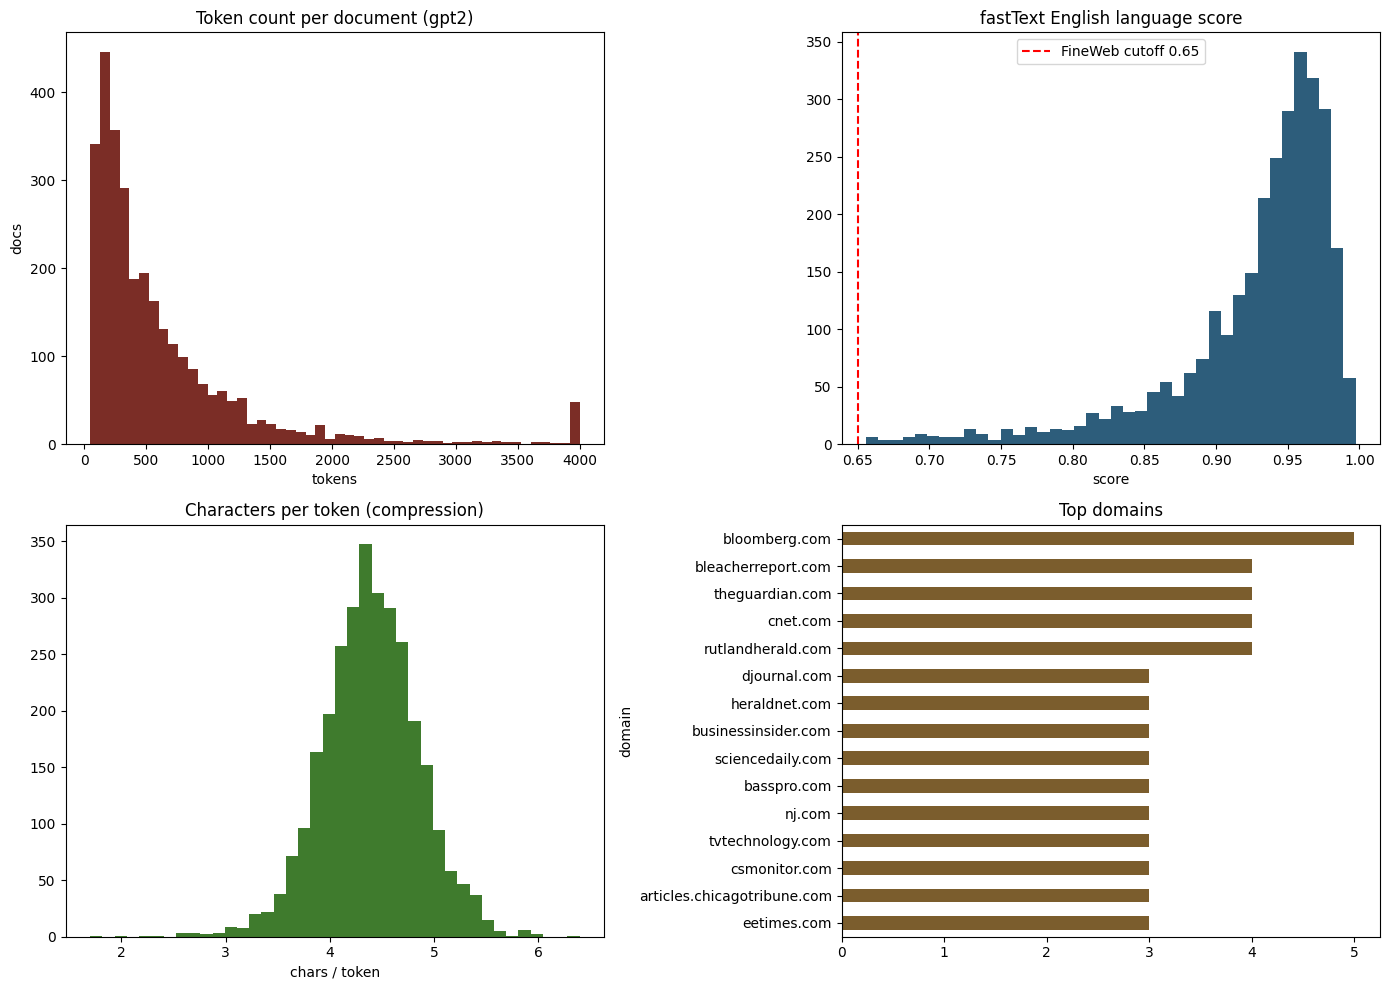


SUMMARY
Docs streamed          : 3,000
Total gpt2 tokens       : 2,091,098
Median tokens/doc       : 387
Unique domains          : 2,874
Mean language_score     : 0.927
Near-duplicate pairs    : 0
Docs flagged by filters : 26 / 3000

Next steps:
  • Swap name='sample-10BT' for a real crawl, e.g. name='CC-MAIN-2024-10'
  • Raise N_DOCS for stronger statistics
  • Use the full datatrove pipeline to reproduce FineWeb end-to-end


In [1]:
df["domain"] = df["url"].apply(lambda u: urlparse(u).netloc.replace("www.", "") if isinstance(u, str) else "?")
top_domains = df["domain"].value_counts().head(15)
print("\n--- Top 15 domains in sample ---")
print(top_domains)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["token_count"].clip(upper=4000), bins=50, color="#7b2d26")
axes[0, 0].set_title("Token count per document (gpt2)")
axes[0, 0].set_xlabel("tokens"); axes[0, 0].set_ylabel("docs")

axes[0, 1].hist(df["language_score"], bins=40, color="#2d5d7b")
axes[0, 1].axvline(0.65, color="red", ls="--", label="FineWeb cutoff 0.65")
axes[0, 1].set_title("fastText English language score")
axes[0, 1].set_xlabel("score"); axes[0, 1].legend()

axes[1, 0].hist(df["chars_per_token"].clip(upper=8), bins=40, color="#3f7b2d")
axes[1, 0].set_title("Characters per token (compression)")
axes[1, 0].set_xlabel("chars / token")

top_domains.iloc[::-1].plot(kind="barh", ax=axes[1, 1], color="#7b5d2d")
axes[1, 1].set_title("Top domains")

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Docs streamed          : {len(df):,}")
print(f"Total gpt2 tokens       : {df['token_count'].sum():,}")
print(f"Median tokens/doc       : {int(df['token_count'].median())}")
print(f"Unique domains          : {df['domain'].nunique():,}")
print(f"Mean language_score     : {df['language_score'].mean():.3f}")
print(f"Near-duplicate pairs    : {len(dup_pairs)}")
print(f"Docs flagged by filters : {(pd.Series(results) != 'kept').sum()} / {len(results)}")
print("\nNext steps:")
print("  • Swap name='sample-10BT' for a real crawl, e.g. name='CC-MAIN-2024-10'")
print("  • Raise N_DOCS for stronger statistics")
print("  • Use the full datatrove pipeline to reproduce FineWeb end-to-end")